# num_boost_round 感度分析

設計書: `designs/pending/06_rounds_sensitivity.md`

ラウンド数を変化させたときの OOS IC の推移を測定し、現行設定 (300) の適切性を確認する。

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.processing import load_and_clean_data
from src.features import generate_features
from src.pooling import pool_boj_data
from src.modeling import walk_forward_validation

EXCEL_PATH   = '../data/BOJ_data.xlsx'
MEETING_PATH = '../data/BOJ_meeting_history.csv'
START_DATE   = '2024-01-01'

df_raw    = load_and_clean_data(EXCEL_PATH, MEETING_PATH)
df_feat   = generate_features(df_raw)
df_pooled = pool_boj_data(df_feat)

print(f'データ準備完了: {len(df_pooled):,} 行')

データ準備完了: 50,639 行


In [2]:
ROUNDS_LIST = [100, 200, 300, 500, 700, 1000]

records = []

for rounds in ROUNDS_LIST:
    print(f'rounds={rounds} を実行中...')

    res_3d = walk_forward_validation(
        df_pooled, 'Target_3d_norm', START_DATE, num_boost_round=rounds
    )
    res_5d = walk_forward_validation(
        df_pooled, 'Target_5d_norm', START_DATE, num_boost_round=rounds
    )

    # OOS IC（全体）
    ic_3d, _ = spearmanr(res_3d['Actual'], res_3d['Pred'])
    ic_5d, _ = spearmanr(res_5d['Actual'], res_5d['Pred'])

    # Train IC（過学習の確認用）
    train_ic_3d = res_3d['Train_IC'].mean()
    train_ic_5d = res_5d['Train_IC'].mean()

    records.append({
        'rounds':       rounds,
        'OOS_IC_3d':    round(ic_3d, 4),
        'OOS_IC_5d':    round(ic_5d, 4),
        'Train_IC_3d':  round(train_ic_3d, 4),
        'Train_IC_5d':  round(train_ic_5d, 4),
        'Gap_3d':       round(train_ic_3d - ic_3d, 4),
        'Gap_5d':       round(train_ic_5d - ic_5d, 4),
    })

df_results = pd.DataFrame(records)
print(df_results.to_string(index=False))

rounds=100 を実行中...


rounds=200 を実行中...


rounds=300 を実行中...


rounds=500 を実行中...


rounds=700 を実行中...


rounds=1000 を実行中...


 rounds  OOS_IC_3d  OOS_IC_5d  Train_IC_3d  Train_IC_5d  Gap_3d  Gap_5d
    100     0.2038     0.2174       0.5033       0.5468  0.2994  0.3294
    200     0.1936     0.2231       0.5908       0.6434  0.3972  0.4202
    300     0.1860     0.2212       0.6462       0.7032  0.4602  0.4819
    500     0.1776     0.2215       0.7178       0.7745  0.5403  0.5530
    700     0.1721     0.2163       0.7655       0.8182  0.5934  0.6019
   1000     0.1650     0.2137       0.8098       0.8566  0.6448  0.6429


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_77108/643309928.py:16: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_77108/643309928.py:16: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_77108/643309928.py:16: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_77108/643309928.py:16: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_77108/643309928.py:16: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/

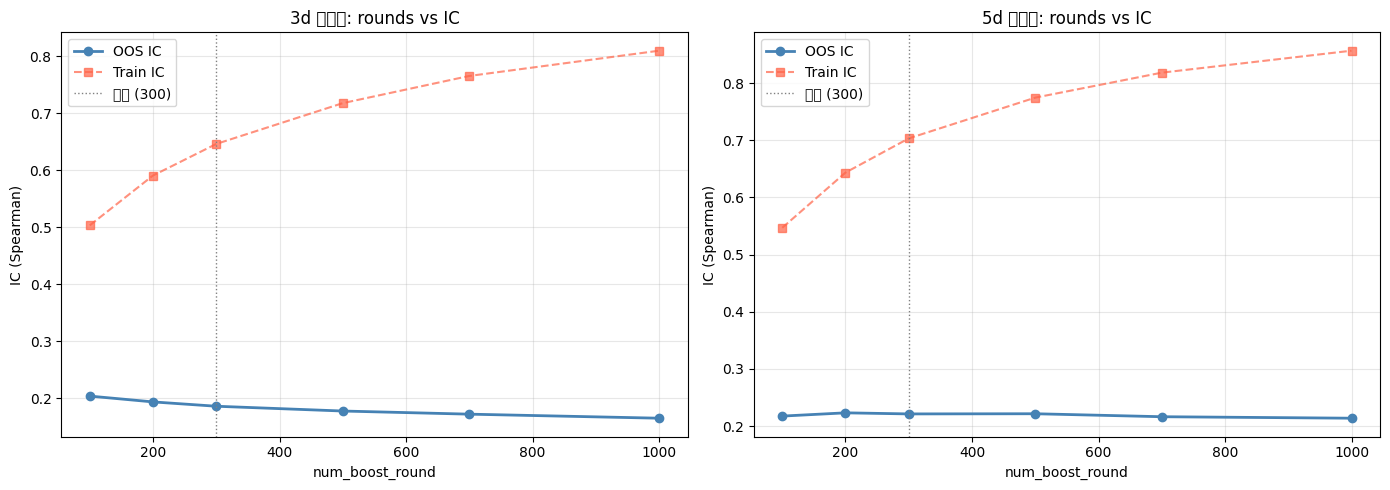

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, oos_col, train_col, gap_col, label in [
    (axes[0], 'OOS_IC_3d', 'Train_IC_3d', 'Gap_3d', '3d モデル'),
    (axes[1], 'OOS_IC_5d', 'Train_IC_5d', 'Gap_5d', '5d モデル'),
]:
    ax.plot(df_results['rounds'], df_results[oos_col],  'o-', label='OOS IC', color='steelblue', linewidth=2)
    ax.plot(df_results['rounds'], df_results[train_col], 's--', label='Train IC', color='tomato', linewidth=1.5, alpha=0.7)
    ax.axvline(300, color='gray', linestyle=':', linewidth=1, label='現行 (300)')
    ax.set_title(f'{label}: rounds vs IC')
    ax.set_xlabel('num_boost_round')
    ax.set_ylabel('IC (Spearman)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../designs/pending/rounds_sensitivity_result.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# 現行(300) と各 rounds の OOS IC 差分を表示
baseline_3d = df_results.loc[df_results['rounds'] == 300, 'OOS_IC_3d'].values[0]
baseline_5d = df_results.loc[df_results['rounds'] == 300, 'OOS_IC_5d'].values[0]

df_results['Delta_IC_3d'] = (df_results['OOS_IC_3d'] - baseline_3d).round(4)
df_results['Delta_IC_5d'] = (df_results['OOS_IC_5d'] - baseline_5d).round(4)

print('=== 現行(300) との OOS IC 差分 ===')
print(df_results[['rounds', 'OOS_IC_3d', 'Delta_IC_3d', 'OOS_IC_5d', 'Delta_IC_5d', 'Gap_3d', 'Gap_5d']].to_string(index=False))

# 推奨 rounds を自動判定（OOS IC が最大の rounds）
best_rounds_3d = df_results.loc[df_results['OOS_IC_3d'].idxmax(), 'rounds']
best_rounds_5d = df_results.loc[df_results['OOS_IC_5d'].idxmax(), 'rounds']
print(f'\n推奨 rounds: 3d={best_rounds_3d}, 5d={best_rounds_5d}')
print('（3d と 5d で異なる場合は大きい方、または両方のICが高い中間値を検討）')

=== 現行(300) との OOS IC 差分 ===
 rounds  OOS_IC_3d  Delta_IC_3d  OOS_IC_5d  Delta_IC_5d  Gap_3d  Gap_5d
    100     0.2038       0.0178     0.2174      -0.0038  0.2994  0.3294
    200     0.1936       0.0076     0.2231       0.0019  0.3972  0.4202
    300     0.1860       0.0000     0.2212       0.0000  0.4602  0.4819
    500     0.1776      -0.0084     0.2215       0.0003  0.5403  0.5530
    700     0.1721      -0.0139     0.2163      -0.0049  0.5934  0.6019
   1000     0.1650      -0.0210     0.2137      -0.0075  0.6448  0.6429

推奨 rounds: 3d=100, 5d=200
（3d と 5d で異なる場合は大きい方、または両方のICが高い中間値を検討）
